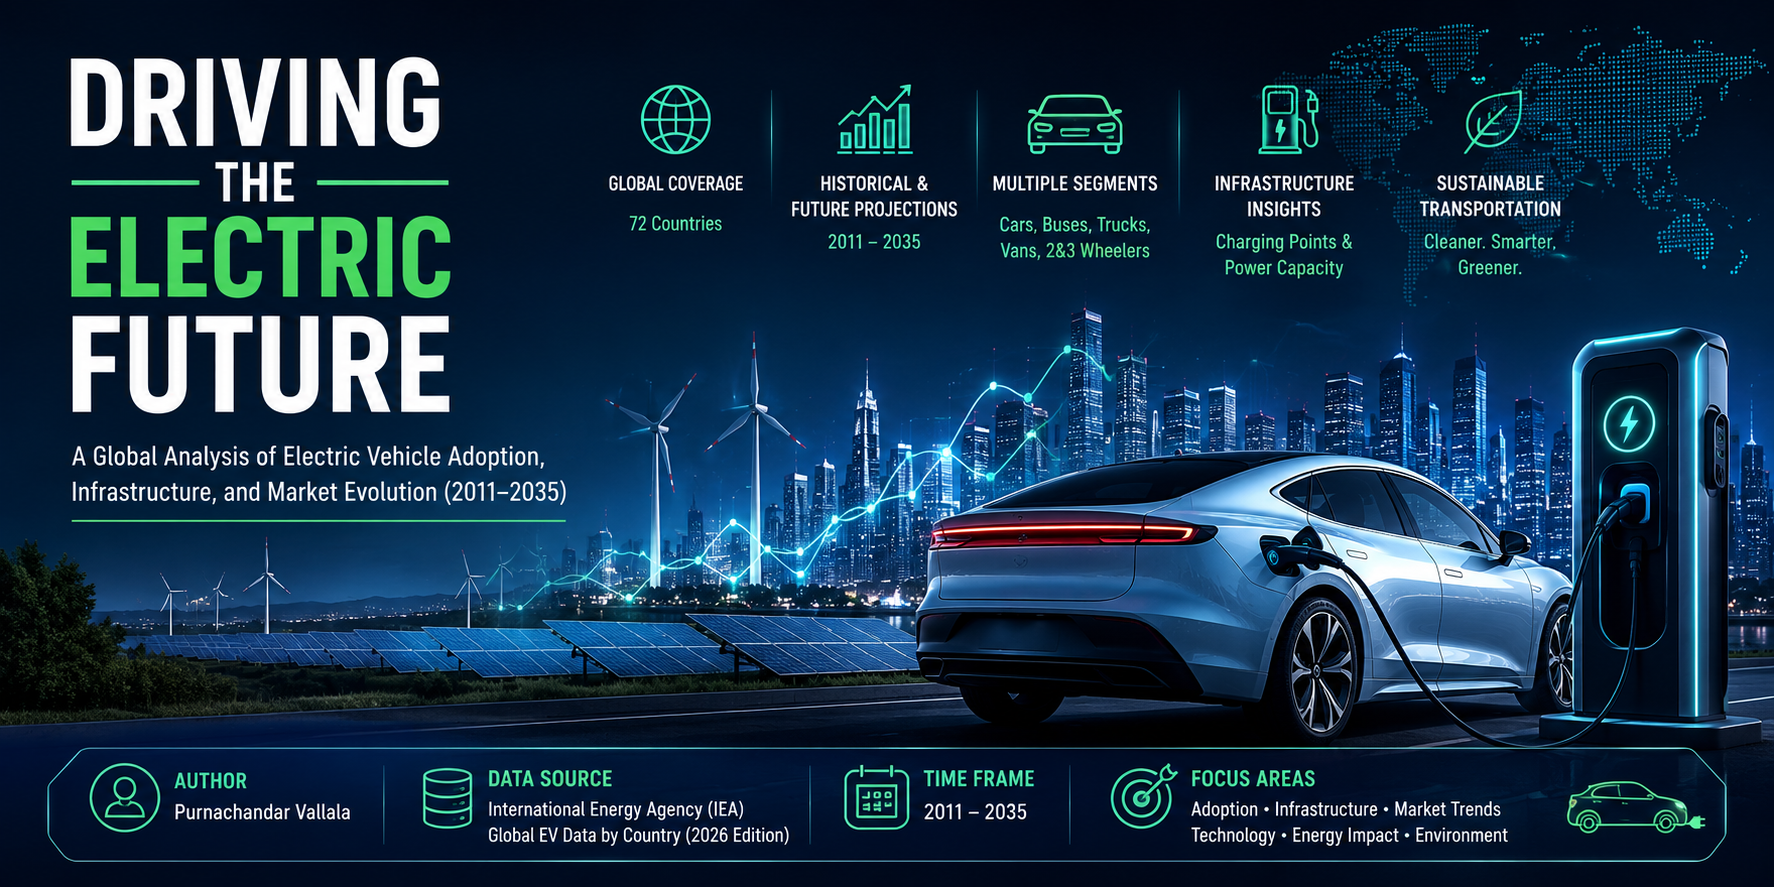

In [1]:
from IPython.display import Image, display

display(Image(filename="../images/cover_banner.png", width=1400))

# Driving the Electric Future: A Global Analysis of Electric Vehicle Adoption, Infrastructure, and Market Evolution (2011–2035)

## Notebook 01 — Data Audit and Preprocessing

---

### Final Individual Project

**Course:** Data Visualization  
**Author:** Purnachandar Vallala  
**Dataset Provider:** International Energy Agency (IEA) – Global EV Data by Country (2026 Edition)

---

## Project Overview

The global transition toward electric mobility is transforming the automotive industry, national energy systems, and climate policy. Governments, manufacturers, and infrastructure providers are investing heavily in electric vehicle (EV) technologies to accelerate sustainable transportation and reduce dependence on fossil fuels.

This project investigates the evolution of the global electric vehicle ecosystem using the official **International Energy Agency (IEA)** dataset. The analysis explores historical developments, evaluates market trends across countries and vehicle technologies, and examines future projections under different policy scenarios.

The complete project consists of three stages:

- **Notebook 01:** Data Audit and Preprocessing
- **Notebook 02:** Exploratory Data Analysis
- **Notebook 03:** Business Insights and Interactive Visualizations

The final outcome will be an interactive Streamlit dashboard supported by publication-quality Plotly visualizations and a professional presentation.

---

## Objectives of this Notebook

This notebook establishes a reliable analytical foundation by performing a comprehensive audit of the raw dataset before any exploratory analysis or visualization begins.

The objectives are to:

- Import and inspect the official IEA dataset.
- Understand the workbook structure and available data.
- Assess dataset completeness and consistency.
- Examine missing values and duplicate records.
- Validate categorical variables and temporal coverage.
- Apply only necessary preprocessing while preserving the integrity of the original data.
- Export a validated dataset for subsequent analysis.

---

## Data Processing Philosophy

Data preprocessing should improve data quality without altering the underlying information. Every modification performed in this notebook will be validated and documented to ensure transparency, reproducibility, and analytical reliability.

The resulting dataset will serve as the single source of truth for all subsequent notebooks, dashboard components, and visualizations developed throughout this project.

---

## Expected Deliverable

At the completion of this notebook, a cleaned and validated dataset will be exported to:

`data/processed/ev_cleaned.csv`

This processed dataset will be used throughout the remainder of the project to ensure consistency across all analyses and visualizations.

In [2]:
# ==========================================================
# Import Required Libraries
# Project: Driving the Electric Future
# ==========================================================

# Standard Library
from pathlib import Path
import warnings

# Data Manipulation
import numpy as np
import pandas as pd

# Notebook Display
from IPython.display import display, Markdown

# Configuration
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [3]:
# ==========================================================
# Project Configuration
# ==========================================================

PROJECT_NAME = "Driving the Electric Future"

AUTHOR = "Purnachandar Vallala"

COURSE = "Data Visualization"

DATASET_PROVIDER = (
    "International Energy Agency (IEA)"
)

DATASET_NAME = (
    "Global EV Data by Country (2026 Edition)"
)

NOTEBOOK = "01_Data_Audit_and_Preprocessing"

VERSION = "1.0"

print(f"Project        : {PROJECT_NAME}")
print(f"Author         : {AUTHOR}")
print(f"Course         : {COURSE}")
print(f"Dataset Source : {DATASET_PROVIDER}")
print(f"Notebook       : {NOTEBOOK}")
print(f"Version        : {VERSION}")

Project        : Driving the Electric Future
Author         : Purnachandar Vallala
Course         : Data Visualization
Dataset Source : International Energy Agency (IEA)
Notebook       : 01_Data_Audit_and_Preprocessing
Version        : 1.0


In [4]:
# ==========================================================
# Project Directory Structure
# ==========================================================

PROJECT_ROOT = Path("..")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

IMAGE_DIR = PROJECT_ROOT / "images"

DASHBOARD_DIR = PROJECT_ROOT / "dashboard"

PRESENTATION_DIR = PROJECT_ROOT / "presentation"

print("Project directories configured successfully.")

Project directories configured successfully.


In [5]:
# ==========================================================
# Locate Dataset
# ==========================================================

excel_files = list(RAW_DATA_DIR.glob("*.xlsx"))

if len(excel_files) == 0:
    raise FileNotFoundError(
        "No Excel dataset found inside data/raw/"
    )

if len(excel_files) > 1:
    raise ValueError(
        "Multiple Excel files found. Keep only one dataset inside data/raw/."
    )

excel_path = excel_files[0]

print("Dataset located successfully.")
print(f"\nFile Name : {excel_path.name}")

Dataset located successfully.

File Name : EV data by country 2026.xlsx


---

# 1. Workbook Inspection

The IEA dataset is distributed as a multi-sheet Excel workbook containing the primary analytical dataset together with supporting documentation, definitions, and supplementary reference tables.

Before loading the data, the workbook structure is inspected to identify:

- the available worksheets,
- supporting documentation,
- metadata,
- and the primary dataset that will be used throughout the analysis.

Understanding the workbook structure ensures that the correct data source is selected and improves the transparency and reproducibility of the analysis.

In [6]:
# ==========================================================
# Inspect Workbook Structure
# ==========================================================

workbook = pd.ExcelFile(excel_path)

sheet_summary = pd.DataFrame({
    "Sheet No.": range(1, len(workbook.sheet_names)+1),
    "Worksheet": workbook.sheet_names
})

display(sheet_summary)

,Sheet No.,Worksheet
0,1,GEVO_EV_2026
1,2,Notes
2,3,Definitions
3,4,Examples >>
4,5,EV sales countries
5,6,EV sales macro regions
6,7,FCEV stock macro regions
7,8,Other than sales and stock
8,9,Regions and countries


## Workbook Assessment

The workbook contains several supporting worksheets that provide metadata, documentation, definitions, and reference tables.

For this project, the primary analytical dataset is stored in the **GEVO_EV_2026** worksheet.

The remaining worksheets will be used as reference material whenever additional clarification regarding variables, definitions, or methodology is required.

In [7]:
# ==========================================================
# Load Primary Dataset
# ==========================================================

PRIMARY_SHEET = workbook.sheet_names[0]

df = pd.read_excel(
    excel_path,
    sheet_name=PRIMARY_SHEET
)

print("Primary dataset loaded successfully.\n")

print(f"Worksheet : {PRIMARY_SHEET}")

print(f"Rows       : {len(df):,}")

print(f"Columns    : {len(df.columns)}")

Primary dataset loaded successfully.

Worksheet : GEVO_EV_2026
Rows       : 49,375
Columns    : 9


---

# 2. Dataset Overview

The purpose of this section is to obtain an initial understanding of the dataset before any preprocessing is performed.

The assessment focuses on:

- overall dataset dimensions,
- feature composition,
- temporal coverage,
- geographical coverage,
- vehicle categories,
- and analytical variables available for further investigation.

In [8]:
# ==========================================================
# Dataset Summary
# ==========================================================

dataset_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Countries",
        "Parameters",
        "Vehicle Modes",
        "Powertrains",
        "Categories",
        "Year Coverage"
    ],
    "Value": [
        f"{len(df):,}",
        len(df.columns),
        df["region_country"].nunique(),
        df["parameter"].nunique(),
        df["mode"].nunique(),
        df["powertrain"].nunique(),
        df["category"].nunique(),
        f"{df['year'].min()} – {df['year'].max()}"
    ]
})

dataset_summary

,Metric,Value
0,Total Records,"49,375"
1,Total Features,9
2,Countries,72
3,Parameters,19
4,Vehicle Modes,13
5,Powertrains,10
6,Categories,3
7,Year Coverage,2010 – 2035


### Interpretation

The dataset contains nearly fifty thousand observations describing the global electric vehicle ecosystem across multiple countries, vehicle technologies, and policy scenarios.

The combination of historical observations and future projections provides a strong foundation for analyzing market evolution, infrastructure development, battery deployment, energy demand, and policy impacts.

The breadth of the dataset makes it suitable for both exploratory analysis and interactive business intelligence applications.

In [9]:
# ==========================================================
# Feature Overview
# ==========================================================

feature_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Values": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

feature_summary

,Column,Data Type,Non-Null Values,Missing Values,Unique Values
region_country,region_country,object,48297,1078,72
category,category,object,49375,0,3
parameter,parameter,object,49375,0,19
mode,mode,object,49375,0,13
powertrain,powertrain,object,49375,0,10
year,year,int64,49375,0,17
unit,unit,object,26793,22582,9
value,value,float64,49375,0,1142
Aggregate group,Aggregate group,object,49375,0,6


## 2.1 Feature Assessment

The dataset contains a compact set of nine variables that describe geographical information, analytical indicators, vehicle technologies, temporal coverage, measurement units, and observed values.

Each feature serves a distinct analytical purpose and together they provide sufficient information to support descriptive, comparative, and predictive analyses throughout the remainder of the project.

In [10]:
# ==========================================================
# Data Dictionary
# ==========================================================

data_dictionary = pd.DataFrame({
    "Column": [
        "region_country",
        "category",
        "parameter",
        "mode",
        "powertrain",
        "year",
        "unit",
        "value",
        "Aggregate group"
    ],
    "Description": [
        "Country or region associated with the observation.",
        "Historical data or future policy scenario.",
        "Metric being measured.",
        "Vehicle segment or charging infrastructure type.",
        "Vehicle powertrain technology.",
        "Observation year.",
        "Measurement unit for the metric.",
        "Observed numerical value.",
        "Regional aggregation classification."
    ]
})

data_dictionary

,Column,Description
0,region_country,Country or region associated with the observat...
1,category,Historical data or future policy scenario.
2,parameter,Metric being measured.
3,mode,Vehicle segment or charging infrastructure type.
4,powertrain,Vehicle powertrain technology.
5,year,Observation year.
6,unit,Measurement unit for the metric.
7,value,Observed numerical value.
8,Aggregate group,Regional aggregation classification.


---

# 3. Data Quality Assessment

Before any preprocessing is performed, the quality of the dataset must be evaluated.

The objective of this section is to assess the completeness, consistency, and integrity of the data by examining:

- Missing values
- Duplicate records
- Data types
- Categorical variables
- Temporal consistency

Rather than applying automatic cleaning operations, each issue will be investigated individually to determine whether corrective action is necessary.

In [11]:
# ==========================================================
# Missing Value Assessment
# ==========================================================

missing_summary = (
    pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isna().sum().values,
        "Percentage (%)": (
            df.isna().sum().values / len(df) * 100
        ).round(2)
    })
    .sort_values("Missing Values", ascending=False)
)

display(
    missing_summary.style
        .hide(axis="index")
        .background_gradient(
            subset=["Missing Values"],
            cmap="Reds"
        )
)

Column,Missing Values,Percentage (%)
unit,22582,45.740000
region_country,1078,2.180000
category,0,0.000000
parameter,0,0.000000
mode,0,0.000000
powertrain,0,0.000000
year,0,0.000000
value,0,0.000000
Aggregate group,0,0.000000


### Missing Value Assessment

The assessment indicates that missing values occur in only two variables:

- **region_country**
- **unit**

At this stage, these values are **not treated as data quality issues** because they may correspond to regional aggregates, global summaries, or parameter-specific observations where a measurement unit is not applicable.

The nature of these missing values will be investigated before any preprocessing decision is made.

In [12]:
# ==========================================================
# Investigating Missing Countries
# ==========================================================

missing_country = df[df["region_country"].isna()]

display(
    missing_country.head(15)
)

print(f"Total observations : {len(missing_country)}")

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
20772,NaN,Historical,price_p0_2025USD,City car,ICEV,2010,NaN,"4,900.00",Other
20773,NaN,Historical,price_p0_2025USD,Large car,ICEV,2010,NaN,"8,500.00",Other
20774,NaN,Historical,price_p0_2025USD,Large SUV/Pick-up,ICEV,2010,NaN,"26,000.00",Other
20775,NaN,Historical,price_p0_2025USD,Medium car,ICEV,2010,NaN,"4,900.00",Other
20776,NaN,Historical,price_p0_2025USD,Small SUV/Pick-up,ICEV,2010,NaN,"7,200.00",Other
20854,NaN,Historical,price_p0_2025USD,City car,BEV,2011,NaN,"45,000.00",Other
20855,NaN,Historical,price_p0_2025USD,City car,ICEV,2011,NaN,"4,800.00",Other
20856,NaN,Historical,price_p0_2025USD,Large car,ICEV,2011,NaN,"22,000.00",Other
20857,NaN,Historical,price_p0_2025USD,Large SUV/Pick-up,ICEV,2011,NaN,"26,000.00",Other
20858,NaN,Historical,price_p0_2025USD,Medium car,ICEV,2011,NaN,"4,800.00",Other


Total observations : 1078


In [13]:
# ==========================================================
# Investigating Missing Units
# ==========================================================

missing_unit = df[df["unit"].isna()]

display(
    missing_unit["parameter"]
        .value_counts()
        .to_frame("Count")
)

,Count
parameter,
price_p0_2025USD,3226
price_p100_2025USD,3226
price_p25_2025USD,3226
price_p50_2025USD,3226
price_p75_2025USD,3226
price_p95_2025USD,3226
price_mean_2025USD,3226


### Missing Value Conclusion

The missing value assessment indicates that the dataset is highly complete.

Only two variables contain missing observations:

- **region_country**
- **unit**

Further investigation shows that the missing values in **unit** are associated exclusively with vehicle price indicators. These observations do not represent incomplete records but rather parameter-specific characteristics of the dataset.

Similarly, missing values in **region_country** are expected to correspond to aggregate or non-country-specific observations.

Based on this assessment, no imputation or deletion is performed at this stage.

---

# 4. Duplicate Record Assessment

Duplicate observations can negatively affect statistical summaries and visualizations if they represent repeated records rather than legitimate measurements.

This section investigates duplicate rows before any preprocessing decision is taken.

Rather than removing duplicates immediately, the duplicated observations will first be inspected to verify whether they are exact duplicates or meaningful repeated measurements.

In [14]:
# ==========================================================
# Duplicate Assessment
# ==========================================================

duplicate_count = df.duplicated().sum()

duplicate_summary = pd.DataFrame({
    "Metric": ["Duplicate Rows"],
    "Value": [duplicate_count]
})

display(
    duplicate_summary.style.hide(axis="index")
)

Metric,Value
Duplicate Rows,15


## 4.1 Duplicate Record Investigation

The duplicate assessment identified **15 duplicated observations** in the dataset.

Before removing any records, the duplicated observations are inspected to verify whether they represent exact duplicates or legitimate repeated measurements.

This validation step ensures that only redundant records are removed while preserving the integrity of the original dataset.

In [15]:
# ==========================================================
# Duplicate Record Investigation
# ==========================================================

duplicate_records = (
    df[df.duplicated(keep=False)]
    .sort_values(
        by=[
            "region_country",
            "parameter",
            "year"
        ]
    )
)

duplicate_records = duplicate_records[
    [
        "region_country",
        "parameter",
        "mode",
        "powertrain",
        "year",
        "value"
    ]
]

display(duplicate_records)

,region_country,parameter,mode,powertrain,year,value
19623,United Arab Emirates,Average capacity per EV,EV,EV,2021,0.31
19805,United Arab Emirates,Average capacity per EV,EV,EV,2021,0.31
19663,United Arab Emirates,Average capacity per EV,EV,EV,2022,0.12
19808,United Arab Emirates,Average capacity per EV,EV,EV,2022,0.12
19703,United Arab Emirates,Average capacity per EV,EV,EV,2023,0.07
19812,United Arab Emirates,Average capacity per EV,EV,EV,2023,0.07
19743,United Arab Emirates,Average capacity per EV,EV,EV,2024,0.05
19816,United Arab Emirates,Average capacity per EV,EV,EV,2024,0.05
19783,United Arab Emirates,Average capacity per EV,EV,EV,2025,0.10
19820,United Arab Emirates,Average capacity per EV,EV,EV,2025,0.10


### Duplicate Investigation Conclusion

Inspection of the duplicated observations confirms that all identified duplicates are exact record repetitions.

Each duplicated row contains identical values across all variables, indicating redundant records rather than separate measurements or scenario-specific observations.

To preserve data integrity and prevent repeated observations from influencing subsequent analyses, only these exact duplicate rows will be removed during preprocessing.

In [16]:
# ==========================================================
# Remove Exact Duplicate Records
# ==========================================================

rows_before = len(df)

df_clean = df.drop_duplicates().copy()

rows_after = len(df_clean)

duplicates_removed = rows_before - rows_after

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Duplicates removed   : {duplicates_removed}")

Rows before cleaning : 49,375
Rows after cleaning  : 49,360
Duplicates removed   : 15


In [17]:
# ==========================================================
# Validation After Cleaning
# ==========================================================

validation_summary = pd.DataFrame({
    "Validation Check": [
        "Duplicate Rows Remaining",
        "Total Records",
        "Total Features",
        "Missing Country Values",
        "Missing Unit Values"
    ],
    "Result": [
        df_clean.duplicated().sum(),
        len(df_clean),
        len(df_clean.columns),
        df_clean["region_country"].isna().sum(),
        df_clean["unit"].isna().sum()
    ]
})

display(
    validation_summary.style.hide(axis="index")
)

Validation Check,Result
Duplicate Rows Remaining,0
Total Records,49360
Total Features,9
Missing Country Values,1078
Missing Unit Values,22582


---

## 5. Data Cleaning Summary

The preprocessing stage focused on improving data quality while preserving the integrity of the original dataset.

The following actions were performed:

- Investigated missing values without unnecessary imputation.
- Verified that missing values correspond to expected dataset characteristics.
- Inspected duplicated observations individually.
- Removed only exact duplicate records.
- Validated the dataset after preprocessing.

The resulting dataset is now suitable for exploratory analysis, visualization, and dashboard development.

In [18]:
# ==========================================================
# Preprocessing Report
# ==========================================================

preprocessing_report = pd.DataFrame({
    "Task": [
        "Original Records",
        "Duplicate Records Removed",
        "Final Records",
        "Missing Values Imputed",
        "Rows Deleted Due to Missing Values",
        "Dataset Ready for Analysis"
    ],
    "Outcome": [
        f"{rows_before:,}",
        duplicates_removed,
        f"{rows_after:,}",
        "No",
        "0",
        "Yes"
    ]
})

display(
    preprocessing_report.style.hide(axis="index")
)

Task,Outcome
Original Records,"49,375"
Duplicate Records Removed,15
Final Records,"49,360"
Missing Values Imputed,No
Rows Deleted Due to Missing Values,0
Dataset Ready for Analysis,Yes


In [20]:
# ==========================================================
# Export Clean Dataset
# ==========================================================

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

output_file = PROCESSED_DATA_DIR / "ev_analysis_ready.csv"

df_clean.to_csv(
    output_file,
    index=False
)

print("Clean dataset exported successfully.")
print(f"Location: {output_file}")

Clean dataset exported successfully.
Location: ..\data\processed\ev_analysis_ready.csv


## Key Findings

The data audit and preprocessing process produced the following findings:

- The original dataset contains **49,375 observations** across **72 countries** and **17 years (2011–2025)**.
- The workbook includes multiple reference sheets, with **GEVO_EV_2026** identified as the primary analytical dataset.
- The dataset contains **9 analytical variables** describing market indicators, vehicle technologies, charging infrastructure, and policy scenarios.
- Missing values are limited to the **region_country** and **unit** variables.
- Investigation confirmed that these missing values represent expected dataset characteristics rather than data quality issues; therefore, they were intentionally preserved.
- A total of **15 exact duplicate records** were identified, verified, and removed.
- The resulting dataset contains **49,360 observations** and is validated for downstream exploratory analysis and visualization.

# Conclusion

This notebook established a reliable analytical foundation for the project through a systematic audit and preprocessing of the official International Energy Agency (IEA) Global Electric Vehicle dataset.

The assessment confirmed that the dataset is structurally consistent, geographically comprehensive, and analytically suitable for investigating global electric vehicle adoption, charging infrastructure, battery deployment, and market evolution.

Data quality evaluation identified two categories of missing values that correspond to expected characteristics of the original dataset rather than data integrity issues. These values were intentionally retained to preserve the authenticity of the source data.

Additionally, fifteen redundant duplicate records were identified through detailed inspection and removed without affecting the remaining observations.

The resulting dataset has been validated and exported as an **analysis-ready dataset**, providing a reliable foundation for exploratory data analysis, business intelligence, interactive visualizations, and dashboard development.

The next notebook will build upon this dataset to explore global electric vehicle trends, identify emerging patterns, compare regional markets, and generate actionable insights through exploratory data analysis.